In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import s3fs
import os
from PIL import Image
import torch
from pathlib import Path
import io
os.environ["AWS_ACCESS_KEY_ID"] = 'CDFEWKLZRM0VAJRQCSLU'
os.environ["AWS_SECRET_ACCESS_KEY"] = 'KIRHpMn0NCaR31GRgfXJbt3CO1TdOPStlmzumRVN'
os.environ["AWS_SESSION_TOKEN"] = 'eyJhbGciOiJIUzUxMiIsInR5cCI6IkpXVCJ9.eyJhY2Nlc3NLZXkiOiJDREZFV0tMWlJNMFZBSlJRQ1NMVSIsImFsbG93ZWQtb3JpZ2lucyI6WyIqIl0sImF1ZCI6WyJtaW5pby1kYXRhbm9kZSIsIm9ueXhpYSIsImFjY291bnQiXSwiYXV0aF90aW1lIjoxNzU2Mjc4OTMwLCJhenAiOiJvbnl4aWEiLCJlbWFpbCI6ImFudG9pbmUubGVzYXV2YWdlQGFncmljdWx0dXJlLmdvdXYuZnIiLCJlbWFpbF92ZXJpZmllZCI6dHJ1ZSwiZXhwIjoxNzU2ODg0NTYwLCJmYW1pbHlfbmFtZSI6IkxFU0FVVkFHRSIsImdpdmVuX25hbWUiOiJBbnRvaW5lIiwiZ3JvdXBzIjpbIlVTRVJfT05ZWElBIl0sImlhdCI6MTc1NjI3OTc2MCwiaXNzIjoiaHR0cHM6Ly9hdXRoLmxhYi5zc3BjbG91ZC5mci9hdXRoL3JlYWxtcy9zc3BjbG91ZCIsImp0aSI6Im9ucnRydDphNjZkN2I5OS1iMmExLTNkOWEtMmM0ZS02N2MyNDNlZjYyMzYiLCJsb2NhbGUiOiJmciIsIm5hbWUiOiJBbnRvaW5lIExFU0FVVkFHRSIsInBvbGljeSI6InN0c29ubHkiLCJwcmVmZXJyZWRfdXNlcm5hbWUiOiJhbnRvaW5lbGVzYXV2YWdlIiwicmVhbG1fYWNjZXNzIjp7InJvbGVzIjpbIm9mZmxpbmVfYWNjZXNzIiwidW1hX2F1dGhvcml6YXRpb24iLCJkZWZhdWx0LXJvbGVzLXNzcGNsb3VkIl19LCJyZXNvdXJjZV9hY2Nlc3MiOnsiYWNjb3VudCI6eyJyb2xlcyI6WyJtYW5hZ2UtYWNjb3VudCIsIm1hbmFnZS1hY2NvdW50LWxpbmtzIiwidmlldy1wcm9maWxlIl19fSwicm9sZXMiOlsib2ZmbGluZV9hY2Nlc3MiLCJ1bWFfYXV0aG9yaXphdGlvbiIsImRlZmF1bHQtcm9sZXMtc3NwY2xvdWQiXSwic2NvcGUiOiJvcGVuaWQgcHJvZmlsZSBncm91cHMgZW1haWwiLCJzaWQiOiI4YmYwYzU2ZC1lZjAzLTQ0NzMtYmM4MS1jMjEyMDM2OGJhMzIiLCJzdWIiOiJlOWY4NjIyYy01MzQ2LTRjOGUtOWZmYi1jY2MwMzZjY2ZjZjciLCJ0eXAiOiJCZWFyZXIifQ.o9BplqRnv6Hbu6K_kNmRgGeZ-x5PXWye4lcJVYrKshO0SRhvXKhLaluuYvP6Og-t5yVKaW-8y0zoHFW_e98XYQ'
os.environ["AWS_DEFAULT_REGION"] = 'us-east-1'
# Configuration S3
s3 = s3fs.S3FileSystem(
    client_kwargs={'endpoint_url': 'https://'+'minio.lab.sspcloud.fr'},
    key = os.environ["AWS_ACCESS_KEY_ID"], 
    secret = os.environ["AWS_SECRET_ACCESS_KEY"], 
    token = os.environ["AWS_SESSION_TOKEN"])


# Chemins S3
BUCKET_NAME = "antoinelesauvage"
S3_PREFIX_PREDS = "vergers-france/preds_128_10/"
S3_PREFIX_PATCHES = "vergers-france/patches_2018_128_10/"
S3_PREFIX_RESULTS = "vergers-france/results_im/"

# Chemins S3 complets
preds_path = f"{BUCKET_NAME}/{S3_PREFIX_PREDS}"
patches_path = f"{BUCKET_NAME}/{S3_PREFIX_PATCHES}"
results_path = f"{BUCKET_NAME}/{S3_PREFIX_RESULTS}"

# Liste de noms de classes
class_names = [
    "Background",
    "Meadow", 
    "Soft winter wheat",
    "Corn",
    "Winter barley",
    "Winter rapeseed",
    "Spring barley",
    "Sunflower",
    "Grapevine",
    "Beet",
    "Winter triticale",
    "Winter durum wheat",
    "Fruits, vegetables, flowers",
    "Potatoes",
    "Leguminous fodder",
    "Soybeans",
    "Orchard",
    "Mixed cereal",
    "Sorghum",
    "Void label"
]

# Colormap discrète
cmap = plt.get_cmap("tab20", len(class_names))
norm = BoundaryNorm(np.arange(len(class_names)+1)-0.5, len(class_names))

def load_prediction_file(s3_path):
    """Charge un fichier de prédiction depuis S3"""
    try:
        full_path = f"s3://{s3_path}"
        print(f"Chargement de : {full_path}")
        
        with s3.open(full_path, 'rb') as f:
            if s3_path.endswith('.pt') or s3_path.endswith('.pth'):
                data = torch.load(f, map_location='cpu')
            elif s3_path.endswith('.npy'):
                data = np.load(f)
            else:
                # Supposer que c'est un format torch par défaut
                data = torch.load(f, map_location='cpu')
        return data
    except Exception as e:
        print(f"Erreur lors du chargement de {s3_path}: {e}")
        return None

def load_satellite_image(s3_path):
    """Charge une image satellite depuis S3"""
    try:
        full_path = f"s3://{s3_path}"
        print(f"Chargement image satellite : {full_path}")
        
        with s3.open(full_path, 'rb') as f:
            img = Image.open(f).convert('RGB')
            return np.array(img)
    except Exception as e:
        print(f"Erreur lors du chargement de l'image satellite {s3_path}: {e}")
        return None

def process_semantic_prediction(data):
    """Traite les données de prédiction sémantique"""
    # Adapter selon la structure de vos données
    if isinstance(data, dict) and "pano_semantic" in data:
        pano_semantic = data["pano_semantic"]
        if len(pano_semantic.shape) == 4:  # (batch, classes, H, W)
            pano_semantic = pano_semantic[0]
    else:
        pano_semantic = data
    
    # Conversion si nécessaire
    if hasattr(pano_semantic, "cpu"):
        pano_semantic = pano_semantic.cpu().numpy()
    
    # Obtenir la carte sémantique
    if len(pano_semantic.shape) == 3:  # (classes, H, W)
        semantic_map = np.argmax(pano_semantic, axis=0)
    else:  # Déjà une carte de classes
        semantic_map = pano_semantic
    
    return semantic_map

def create_overlay(satellite_img, semantic_map, alpha=0.6):
    """Crée une superposition semi-transparente"""
    # Créer une image colorée pour la segmentation
    colored_seg = cmap(norm(semantic_map))[:, :, :3]  # Enlever le canal alpha
    colored_seg = (colored_seg * 255).astype(np.uint8)
    
    # Normaliser l'image satellite
    if satellite_img.max() > 1:
        satellite_img = satellite_img.astype(np.float32) / 255.0
    
    # Créer le masque pour éviter le background
    mask = semantic_map != 0  # Supposer que 0 = background
    
    # Superposition
    overlay = satellite_img.copy()
    overlay[mask] = (1 - alpha) * satellite_img[mask] + alpha * (colored_seg[mask] / 255.0)
    
    return overlay

def get_corresponding_satellite_path(pred_filename):
    """Obtient le chemin de l'image satellite correspondante"""
    # Adapter selon votre convention de nommage
    base_name = Path(pred_filename).stem
    
    # Essayer différentes extensions possibles
    possible_extensions = ['.tif', '.tiff', '.jpg', '.jpeg', '.png']
    
    for ext in possible_extensions:
        satellite_name = f"{base_name}{ext}"
        satellite_path = f"{patches_path}{satellite_name}"
        
        # Vérifier si le fichier existe
        try:
            if s3.exists(f"s3://{satellite_path}"):
                return satellite_path
        except:
            continue
    
    # Si aucun fichier trouvé, retourner le chemin avec .tif par défaut
    return f"{patches_path}{base_name}.tif"

# Traitement principal
def process_tiles():
    # Lister les fichiers de prédiction
    try:
        print(f"Recherche des fichiers dans : s3://{preds_path}")
        pred_files = s3.ls(preds_path)
        pred_files = [f for f in pred_files if not f.endswith('/')]  # Enlever les dossiers
        
        print(f"Fichiers trouvés : {len(pred_files)}")
        
        # Prendre les 100 premiers
        pred_files = pred_files[:100]
        print(f"Traitement de {len(pred_files)} tuiles")
        
        # Créer le dossier results s'il n'existe pas
        try:
            s3.mkdir(f"s3://{results_path}")
        except:
            pass  # Le dossier existe déjà
        
        successful_processes = 0
        
        for i, pred_file in enumerate(pred_files):
            print(f"\n=== Traitement {i+1}/{len(pred_files)}: {os.path.basename(pred_file)} ===")
            
            # Charger la prédiction
            pred_data = load_prediction_file(pred_file)
            if pred_data is None:
                continue
            
            # Traiter la prédiction sémantique
            try:
                semantic_map = process_semantic_prediction(pred_data)
                print(f"Carte sémantique : {semantic_map.shape}")
            except Exception as e:
                print(f"Erreur lors du traitement de la prédiction : {e}")
                continue
            
            # Obtenir le chemin de l'image satellite correspondante
            satellite_path = get_corresponding_satellite_path(os.path.basename(pred_file))
            
            # Charger l'image satellite
            satellite_img = load_satellite_image(satellite_path)
            if satellite_img is None:
                print(f"Image satellite non trouvée : {satellite_path}")
                continue
            
            print(f"Image satellite : {satellite_img.shape}")
            
            # Redimensionner si nécessaire
            if satellite_img.shape[:2] != semantic_map.shape:
                print(f"Redimensionnement nécessaire : {satellite_img.shape[:2]} -> {semantic_map.shape}")
                try:
                    from skimage.transform import resize
                    satellite_img = resize(satellite_img, semantic_map.shape, preserve_range=True).astype(np.uint8)
                except ImportError:
                    # Alternative avec PIL si scikit-image n'est pas disponible
                    from PIL import Image as PILImage
                    satellite_pil = PILImage.fromarray(satellite_img)
                    satellite_pil = satellite_pil.resize((semantic_map.shape[1], semantic_map.shape[0]), PILImage.Resampling.LANCZOS)
                    satellite_img = np.array(satellite_pil)
            
            # Créer la superposition
            try:
                overlay = create_overlay(satellite_img, semantic_map, alpha=0.6)
            except Exception as e:
                print(f"Erreur lors de la création de la superposition : {e}")
                continue
            
            # Créer la visualisation
            fig, axes = plt.subplots(1, 3, figsize=(18, 6))
            
            # Image satellite originale
            axes[0].imshow(satellite_img)
            axes[0].set_title("Image satellite")
            axes[0].axis('off')
            
            # Carte sémantique
            im = axes[1].matshow(semantic_map, cmap=cmap, norm=norm)
            axes[1].set_title("Prédiction sémantique")
            
            # Superposition
            axes[2].imshow(overlay)
            axes[2].set_title("Superposition")
            axes[2].axis('off')
            
            # Ajouter la barre de couleur
            cbar = plt.colorbar(im, ax=axes[1], ticks=np.arange(len(class_names)))
            cbar.ax.set_yticklabels(class_names, fontsize=8)
            
            plt.tight_layout()
            
            # Sauvegarder le résultat
            result_filename = f"overlay_{Path(pred_file).stem}.png"
            result_full_path = f"s3://{results_path}{result_filename}"
            
            # Sauvegarder sur S3
            try:
                buffer = io.BytesIO()
                plt.savefig(buffer, format='png', dpi=150, bbox_inches='tight')
                buffer.seek(0)
                
                with s3.open(result_full_path, 'wb') as f:
                    f.write(buffer.getvalue())
                
                successful_processes += 1
                print(f"✓ Résultat sauvegardé : {result_full_path}")
                
            except Exception as e:
                print(f"Erreur lors de la sauvegarde : {e}")
            
            plt.close()
            
        print(f"\n=== Traitement terminé ===")
        print(f"Fichiers traités avec succès : {successful_processes}/{len(pred_files)}")
            
    except Exception as e:
        print(f"Erreur lors du listage des fichiers : {e}")
        print(f"Vérifiez que le bucket '{BUCKET_NAME}' et le préfixe '{S3_PREFIX_PREDS}' existent")

# Fonction utilitaire pour lister les fichiers disponibles
def list_available_files():
    """Liste les fichiers disponibles dans les dossiers preds et patches"""
    print("=== Fichiers dans preds ===")
    try:
        pred_files = s3.ls(preds_path)
        for i, f in enumerate(pred_files[:10]):  # Afficher les 10 premiers
            print(f"{i+1}: {os.path.basename(f)}")
        if len(pred_files) > 10:
            print(f"... et {len(pred_files) - 10} autres fichiers")
    except Exception as e:
        print(f"Erreur : {e}")
    
    print("\n=== Fichiers dans patches ===")
    try:
        patch_files = s3.ls(patches_path)
        for i, f in enumerate(patch_files[:10]):  # Afficher les 10 premiers
            print(f"{i+1}: {os.path.basename(f)}")
        if len(patch_files) > 10:
            print(f"... et {len(patch_files) - 10} autres fichiers")
    except Exception as e:
        print(f"Erreur : {e}")

# Lancer le traitement
if __name__ == "__main__":
    # Optionnel : lister les fichiers disponibles d'abord
    print("Vérification des fichiers disponibles...")
    list_available_files()
    
    # Lancer le traitement principal
    print("\nDémarrage du traitement...")
    process_tiles()

Vérification des fichiers disponibles...
=== Fichiers dans preds ===
1: .keep
2: 0_best_fold_5.npy
3: 1000_best_fold_5.npy
4: 1001_best_fold_5.npy
5: 1002_best_fold_5.npy
6: 1003_best_fold_5.npy
7: 1004_best_fold_5.npy
8: 1005_best_fold_5.npy
9: 1006_best_fold_5.npy
10: 1007_best_fold_5.npy
... et 6622 autres fichiers

=== Fichiers dans patches ===
1: .keep
2: 0.npy
3: 1.npy
4: 10.npy
5: 100.npy
6: 1000.npy
7: 1001.npy
8: 1002.npy
9: 1003.npy
10: 1004.npy
... et 6621 autres fichiers

Démarrage du traitement...
Recherche des fichiers dans : s3://antoinelesauvage/vergers-france/preds_128_10/
Fichiers trouvés : 6632
Traitement de 100 tuiles

=== Traitement 1/100: .keep ===
Chargement de : s3://antoinelesauvage/vergers-france/preds_128_10/.keep
Erreur lors du chargement de antoinelesauvage/vergers-france/preds_128_10/.keep: Weights only load failed. In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` wi

=== Test d'un fichier ===
Test avec le fichier : 0_best_fold_5.npy

--- Chargement de la prédiction ---
Chargement de : s3://antoinelesauvage/vergers-france/preds_128_10/0_best_fold_5.npy
✓ Chargé avec numpy allow_pickle=True
✓ Prédiction chargée avec succès
Type de données de prédiction : <class 'numpy.ndarray'>
Après item() : <class 'dict'>
Clés disponibles : ['center_mask', 'saliency', 'heatmap', 'semantic', 'size', 'confidence', 'centerness', 'instance_masks', 'instance_boxes', 'pano_instance', 'pano_semantic', 'best_fold', 'all_confidences', 'tile_id']
Utilisation de 'pano_semantic'
Shape des prédictions : (1, 20, 128, 128)
Type des prédictions : <class 'numpy.ndarray'>
Dtype : float32
Après suppression du batch : (20, 128, 128)
Application d'argmax sur l'axe 0
Après argmax : (128, 128)
Classes uniques dans la prédiction : [ 0  1  3  7  8 12 14 15 18]
Nombre de pixels par classe :
  Background: 4433 pixels
  Meadow: 2152 pixels
  Corn: 2524 pixels
  Sunflower: 1256 pixels
  Grapev

Shape de l'image satellite : (27, 10, 128, 128)
Type : float64
Min/Max : 54.0/10380.0
Format 4D détecté : (27, 10, 128, 128)
Extrait RGB du dernier timestep : (128, 128, 3)
Image RGB finale : (128, 128, 3), min/max: 0/255
✓ Image satellite chargée : (128, 128, 3)

--- Test de superposition ---
✓ Overlay créé : (128, 128, 3)


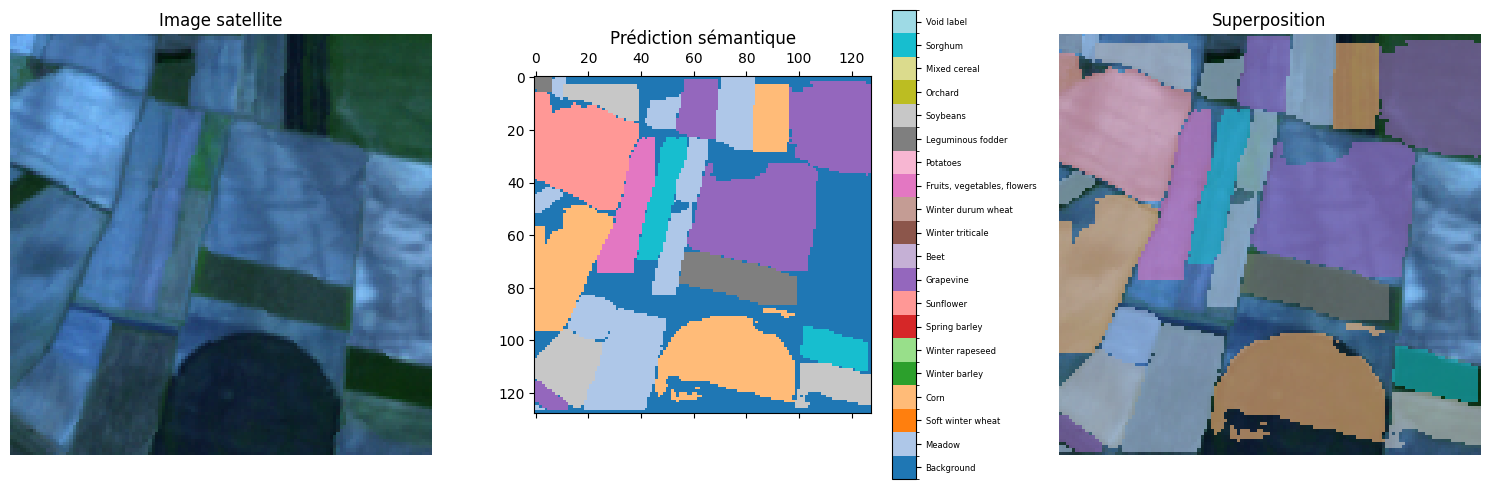


Démarrage du traitement complet...
Recherche des fichiers dans : s3://antoinelesauvage/vergers-france/preds_128_10/
Fichiers valides trouvés : 6630
Traitement de 100 tuiles

=== Traitement 1/100: 0_best_fold_5.npy ===
Chargement de : s3://antoinelesauvage/vergers-france/preds_128_10/0_best_fold_5.npy
✓ Chargé avec numpy allow_pickle=True
Type de données de prédiction : <class 'numpy.ndarray'>
Après item() : <class 'dict'>
Clés disponibles : ['center_mask', 'saliency', 'heatmap', 'semantic', 'size', 'confidence', 'centerness', 'instance_masks', 'instance_boxes', 'pano_instance', 'pano_semantic', 'best_fold', 'all_confidences', 'tile_id']
Utilisation de 'pano_semantic'
Shape des prédictions : (1, 20, 128, 128)
Type des prédictions : <class 'numpy.ndarray'>
Dtype : float32
Après suppression du batch : (20, 128, 128)
Application d'argmax sur l'axe 0
Après argmax : (128, 128)
Classes uniques dans la prédiction : [ 0  1  3  7  8 12 14 15 18]
Nombre de pixels par classe :
  Background: 4433 

In [4]:
# Liste de noms de classes
class_names = [
    "Background",
    "Meadow", 
    "Soft winter wheat",
    "Corn",
    "Winter barley",
    "Winter rapeseed",
    "Spring barley",
    "Sunflower",
    "Grapevine",
    "Beet",
    "Winter triticale",
    "Winter durum wheat",
    "Fruits, vegetables, flowers",
    "Potatoes",
    "Leguminous fodder",
    "Soybeans",
    "Orchard",
    "Mixed cereal",
    "Sorghum",
    "Void label"
]

# Colormap discrète
cmap = plt.get_cmap("tab20", len(class_names))
norm = BoundaryNorm(np.arange(len(class_names)+1)-0.5, len(class_names))

def load_prediction_file(s3_path):
    """Charge un fichier de prédiction depuis S3"""
    try:
        full_path = f"s3://{s3_path}"
        print(f"Chargement de : {full_path}")
        
        with s3.open(full_path, 'rb') as f:
            if s3_path.endswith('.npy'):
                try:
                    data = np.load(f)
                    print("✓ Chargé avec numpy standard")
                    return data
                except:
                    f.seek(0)
                    try:
                        data = np.load(f, allow_pickle=True)
                        print("✓ Chargé avec numpy allow_pickle=True")
                        return data
                    except:
                        f.seek(0)
                        data = torch.load(f, weights_only=False)
                        print("✓ Chargé avec PyTorch")
                        return data
            else:
                data = torch.load(f, weights_only=False)
                return data
        
    except Exception as e:
        print(f"Erreur lors du chargement de {s3_path}: {e}")
        return None

def load_satellite_image(s3_path):
    """Charge une image satellite depuis S3"""
    try:
        full_path = f"s3://{s3_path}"
        print(f"Chargement image satellite : {full_path}")
        
        with s3.open(full_path, 'rb') as f:
            img_array = np.load(f)
            
            print(f"Shape de l'image satellite : {img_array.shape}")
            print(f"Type : {img_array.dtype}")
            print(f"Min/Max : {img_array.min()}/{img_array.max()}")
            
            # Gérer le format multi-canaux/multi-temporal (27, 10, 128, 128)
            if len(img_array.shape) == 4:
                # Format probable : (time_steps, channels, height, width)
                # ou (channels, time_steps, height, width)
                
                print(f"Format 4D détecté : {img_array.shape}")
                
                # Essayer différentes stratégies pour extraire une image RGB
                if img_array.shape[0] == 27 and img_array.shape[1] == 10:
                    # (27, 10, H, W) - probablement (time_steps, channels, H, W)
                    # Prendre le dernier time step et les 3 premiers canaux RGB
                    img_rgb = img_array[-1, :3, :, :]  # (3, H, W)
                    img_rgb = np.transpose(img_rgb, (1, 2, 0))  # (H, W, 3)
                    print(f"Extrait RGB du dernier timestep : {img_rgb.shape}")
                    
                elif img_array.shape[1] == 27 and img_array.shape[0] == 10:
                    # (10, 27, H, W) - probablement (channels, time_steps, H, W)
                    # Prendre les 3 premiers canaux du dernier time step
                    img_rgb = img_array[:3, -1, :, :]  # (3, H, W)
                    img_rgb = np.transpose(img_rgb, (1, 2, 0))  # (H, W, 3)
                    print(f"Extrait RGB des 3 premiers canaux : {img_rgb.shape}")
                    
                else:
                    # Stratégie générale : prendre une sous-partie qui fait du sens
                    # Essayer de prendre quelque chose qui ressemble à (3, H, W)
                    if img_array.shape[0] >= 3:
                        img_rgb = img_array[:3, 0, :, :]  # Prendre les 3 premiers canaux, premier timestep
                    elif img_array.shape[1] >= 3:
                        img_rgb = img_array[0, :3, :, :]  # Premier élément, 3 premiers canaux
                    else:
                        # Fallback : moyenner pour créer une image en niveaux de gris
                        img_gray = np.mean(img_array, axis=(0, 1))  # Moyenner sur les deux premières dimensions
                        img_rgb = np.stack([img_gray] * 3, axis=-1)
                        print(f"Créé RGB à partir de la moyenne : {img_rgb.shape}")
                        return img_rgb.astype(np.uint8)
                    
                    img_rgb = np.transpose(img_rgb, (1, 2, 0))  # (H, W, 3)
                    
            elif len(img_array.shape) == 3:
                if img_array.shape[2] == 3:  # (H, W, 3)
                    img_rgb = img_array
                elif img_array.shape[0] == 3:  # (3, H, W)
                    img_rgb = np.transpose(img_array, (1, 2, 0))
                elif img_array.shape[2] > 3:  # (H, W, C) avec C > 3
                    img_rgb = img_array[:, :, :3]
                else:
                    print(f"Format 3D non géré : {img_array.shape}")
                    return None
                    
            elif len(img_array.shape) == 2:  # (H, W)
                img_rgb = np.stack([img_array] * 3, axis=-1)
                
            else:
                print(f"Format d'image non géré : {img_array.shape}")
                return None
            
            # Normaliser les valeurs si nécessaire
            if img_rgb.max() > 255:
                # Normaliser à [0, 255]
                img_rgb = ((img_rgb - img_rgb.min()) / (img_rgb.max() - img_rgb.min()) * 255).astype(np.uint8)
            else:
                img_rgb = img_rgb.astype(np.uint8)
                
            print(f"Image RGB finale : {img_rgb.shape}, min/max: {img_rgb.min()}/{img_rgb.max()}")
            return img_rgb
            
    except Exception as e:
        print(f"Erreur lors du chargement de l'image satellite {s3_path}: {e}")
        import traceback
        traceback.print_exc()
        return None

def process_semantic_prediction(data):
    """Traite les données de prédiction sémantique"""
    print(f"Type de données de prédiction : {type(data)}")
    
    # Si c'est un objet numpy avec item()
    if isinstance(data, np.ndarray) and data.shape == ():
        data = data.item()
        print(f"Après item() : {type(data)}")
    
    # Si c'est un dictionnaire
    if isinstance(data, dict):
        print(f"Clés disponibles : {list(data.keys())}")
        
        # Utiliser 'pano_semantic' qui est la clé correcte
        if "pano_semantic" in data:
            pano_semantic = data["pano_semantic"]
            print(f"Utilisation de 'pano_semantic'")
        else:
            print("Clé 'pano_semantic' non trouvée")
            return None
    else:
        pano_semantic = data
    
    # Conversion vers numpy si nécessaire
    if hasattr(pano_semantic, "cpu"):
        pano_semantic = pano_semantic.cpu().numpy()
        print("✓ Converti de GPU vers CPU puis numpy")
    elif isinstance(pano_semantic, torch.Tensor):
        pano_semantic = pano_semantic.detach().cpu().numpy()
        print("✓ Détaché et converti vers numpy")
    
    print(f"Shape des prédictions : {pano_semantic.shape}")
    print(f"Type des prédictions : {type(pano_semantic)}")
    print(f"Dtype : {pano_semantic.dtype}")
    
    # Traiter selon la forme
    if len(pano_semantic.shape) == 4:  # (batch, classes, H, W)
        pano_semantic = pano_semantic[0]
        print(f"Après suppression du batch : {pano_semantic.shape}")
    
    if len(pano_semantic.shape) == 3:  # (classes, H, W)
        print("Application d'argmax sur l'axe 0")
        semantic_map = np.argmax(pano_semantic, axis=0)
        print(f"Après argmax : {semantic_map.shape}")
    elif len(pano_semantic.shape) == 2:  # Déjà une carte de classes (H, W)
        semantic_map = pano_semantic
        print("Déjà une carte de classes")
    else:
        print(f"Format de prédiction non géré : {pano_semantic.shape}")
        return None
    
    print(f"Classes uniques dans la prédiction : {np.unique(semantic_map)}")
    print(f"Nombre de pixels par classe :")
    unique, counts = np.unique(semantic_map, return_counts=True)
    for u, c in zip(unique, counts):
        if u < len(class_names):
            print(f"  {class_names[u]}: {c} pixels")
        else:
            print(f"  Classe {u}: {c} pixels")
    
    return semantic_map.astype(int)

def create_overlay(satellite_img, semantic_map, alpha=0.6):
    """Crée une superposition semi-transparente"""
    # Créer une image colorée pour la segmentation
    colored_seg = cmap(norm(semantic_map))[:, :, :3]
    
    # Normaliser l'image satellite
    satellite_img_norm = satellite_img.copy().astype(np.float32)
    if satellite_img_norm.max() > 1:
        satellite_img_norm = satellite_img_norm / 255.0
    
    # Créer le masque pour éviter le background
    mask = semantic_map != 0
    
    # Superposition
    overlay = satellite_img_norm.copy()
    overlay[mask] = (1 - alpha) * satellite_img_norm[mask] + alpha * colored_seg[mask]
    
    return overlay

def get_corresponding_satellite_path(pred_filename):
    """Obtient le chemin de l'image satellite correspondante"""
    base_name = pred_filename.split('_')[0]
    satellite_name = f"{base_name}.npy"
    satellite_path = f"{patches_path}{satellite_name}"
    return satellite_path

def is_valid_file(filename):
    """Vérifie si le fichier est valide"""
    return not filename.startswith('.') and filename.endswith('.npy')

def test_single_file():
    """Teste le traitement d'un seul fichier pour debug"""
    try:
        pred_files = s3.ls(preds_path)
        valid_files = [f for f in pred_files if is_valid_file(os.path.basename(f))]
        
        if not valid_files:
            print("Aucun fichier valide trouvé")
            return False
        
        test_file = valid_files[0]
        pred_basename = os.path.basename(test_file)
        print(f"Test avec le fichier : {pred_basename}")
        
        # Test de chargement de prédiction
        print("\n--- Chargement de la prédiction ---")
        pred_data = load_prediction_file(test_file)
        if pred_data is not None:
            print(f"✓ Prédiction chargée avec succès")
            
            semantic_map = process_semantic_prediction(pred_data)
            if semantic_map is not None:
                print(f"✓ Carte sémantique créée : {semantic_map.shape}")
                
                # Test de chargement de l'image satellite
                print("\n--- Chargement de l'image satellite ---")
                satellite_path = get_corresponding_satellite_path(pred_basename)
                satellite_img = load_satellite_image(satellite_path)
                
                if satellite_img is not None:
                    print(f"✓ Image satellite chargée : {satellite_img.shape}")
                    
                    # Test de création d'overlay
                    print("\n--- Test de superposition ---")
                    if satellite_img.shape[:2] != semantic_map.shape:
                        print(f"Redimensionnement nécessaire : {satellite_img.shape[:2]} -> {semantic_map.shape}")
                        try:
                            from skimage.transform import resize
                            satellite_img = resize(satellite_img, semantic_map.shape, preserve_range=True).astype(np.uint8)
                        except ImportError:
                            from PIL import Image as PILImage
                            satellite_pil = PILImage.fromarray(satellite_img)
                            satellite_pil = satellite_pil.resize((semantic_map.shape[1], semantic_map.shape[0]))
                            satellite_img = np.array(satellite_pil)
                    
                    overlay = create_overlay(satellite_img, semantic_map)
                    print(f"✓ Overlay créé : {overlay.shape}")
                    
                    # Affichage test
                    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
                    
                    axes[0].imshow(satellite_img)
                    axes[0].set_title("Image satellite")
                    axes[0].axis('off')
                    
                    im = axes[1].matshow(semantic_map, cmap=cmap, norm=norm)
                    axes[1].set_title("Prédiction sémantique")
                    
                    axes[2].imshow(overlay)
                    axes[2].set_title("Superposition")
                    axes[2].axis('off')
                    
                    # Ajouter colorbar
                    cbar = plt.colorbar(im, ax=axes[1], ticks=np.arange(len(class_names)))
                    cbar.ax.set_yticklabels(class_names, fontsize=6)
                    
                    plt.tight_layout()
                    plt.show()
                    
                    return True
                else:
                    print("✗ Impossible de charger l'image satellite")
            else:
                print("✗ Impossible de traiter la prédiction")
        else:
            print("✗ Impossible de charger la prédiction")
        
        return False
            
    except Exception as e:
        print(f"Erreur lors du test : {e}")
        import traceback
        traceback.print_exc()
        return False

def process_tiles():
    """Traite les 100 premières tuiles"""
    try:
        print(f"Recherche des fichiers dans : s3://{preds_path}")
        pred_files = s3.ls(preds_path)
        
        # Filtrer les fichiers valides
        pred_files = [f for f in pred_files if is_valid_file(os.path.basename(f))]
        
        print(f"Fichiers valides trouvés : {len(pred_files)}")
        
        # Prendre les 100 premiers
        pred_files = pred_files[:100]
        print(f"Traitement de {len(pred_files)} tuiles")
        
        # Créer le dossier results s'il n'existe pas
        try:
            s3.mkdir(f"s3://{results_path}")
        except:
            pass
        
        successful_processes = 0
        
        for i, pred_file in enumerate(pred_files):
            pred_basename = os.path.basename(pred_file)
            print(f"\n=== Traitement {i+1}/{len(pred_files)}: {pred_basename} ===")
            
            try:
                # Charger la prédiction
                pred_data = load_prediction_file(pred_file)
                if pred_data is None:
                    continue
                
                # Traiter la prédiction sémantique
                semantic_map = process_semantic_prediction(pred_data)
                if semantic_map is None:
                    continue
                
                # Charger l'image satellite correspondante
                satellite_path = get_corresponding_satellite_path(pred_basename)
                satellite_img = load_satellite_image(satellite_path)
                if satellite_img is None:
                    continue
                
                # Redimensionner si nécessaire
                if satellite_img.shape[:2] != semantic_map.shape:
                    try:
                        from skimage.transform import resize
                        satellite_img = resize(satellite_img, semantic_map.shape, preserve_range=True).astype(np.uint8)
                    except ImportError:
                        from PIL import Image as PILImage
                        satellite_pil = PILImage.fromarray(satellite_img)
                        satellite_pil = satellite_pil.resize((semantic_map.shape[1], semantic_map.shape[0]))
                        satellite_img = np.array(satellite_pil)
                
                # Créer la superposition
                overlay = create_overlay(satellite_img, semantic_map, alpha=0.6)
                
                # Créer la visualisation
                fig, axes = plt.subplots(1, 3, figsize=(18, 6))
                
                axes[0].imshow(satellite_img)
                axes[0].set_title(f"Image satellite - {pred_basename.split('_')[0]}")
                axes[0].axis('off')
                
                im = axes[1].matshow(semantic_map, cmap=cmap, norm=norm)
                axes[1].set_title("Prédiction sémantique")
                
                axes[2].imshow(overlay)
                axes[2].set_title("Superposition")
                axes[2].axis('off')
                
                # Ajouter la barre de couleur
                cbar = plt.colorbar(im, ax=axes[1], ticks=np.arange(len(class_names)))
                cbar.ax.set_yticklabels(class_names, fontsize=6)
                
                plt.tight_layout()
                
                # Sauvegarder le résultat
                result_filename = f"overlay_{pred_basename.split('_')[0]}.png"
                result_full_path = f"s3://{results_path}{result_filename}"
                
                buffer = io.BytesIO()
                plt.savefig(buffer, format='png', dpi=150, bbox_inches='tight')
                buffer.seek(0)
                
                with s3.open(result_full_path, 'wb') as f:
                    f.write(buffer.getvalue())
                
                successful_processes += 1
                print(f"✓ Résultat sauvegardé : {result_full_path}")
                
                plt.close()
                
            except Exception as e:
                print(f"Erreur lors du traitement de {pred_basename}: {e}")
                continue
                
        print(f"\n=== Traitement terminé ===")
        print(f"Fichiers traités avec succès : {successful_processes}/{len(pred_files)}")
            
    except Exception as e:
        print(f"Erreur générale : {e}")
        import traceback
        traceback.print_exc()

# Lancer le traitement
if __name__ == "__main__":
    print("=== Test d'un fichier ===")
    success = test_single_file()
    
    if success:
        response = input("\nVoulez-vous continuer avec le traitement complet ? (y/n): ")
        if response.lower() == 'y':
            print("\nDémarrage du traitement complet...")
            process_tiles()
    else:
        print("Le test a échoué. Vérifiez les erreurs ci-dessus.")

=== CONTENU DES DOSSIERS ===

--- Fichiers dans vergers-france/patches_2018_128_10/ ---
Nombre de fichiers .npy : 6630
  1: 0.npy
  2: 1.npy
  3: 10.npy
  4: 100.npy
  5: 1000.npy
  ... et 6625 autres

--- Fichiers dans vergers-france/patches_test/ ---
Nombre de fichiers .npy : 24
  1: S2_10001.npy
  2: S2_10005.npy
  3: S2_10010.npy
  4: S2_10013.npy
  5: S2_10017.npy
  6: S2_10019.npy
  7: S2_10025.npy
  8: S2_10036.npy
  9: S2_10038.npy
  10: S2_10043.npy
  ... et 14 autres

S2_10004.npy trouvé : ✓

=== CHARGEMENT DES IMAGES ===
Tuile normale sélectionnée : 500.npy

=== Analyse de 500.npy ===
Chargement de : s3://antoinelesauvage/vergers-france/patches_2018_128_10/500.npy
Shape : (24, 10, 128, 128)
Dtype : float64
Min/Max : 1.00/10392.00
Mean : 1916.44
Std : 1186.69

=== Analyse de S2_10038.npy ===
Chargement de : s3://antoinelesauvage/vergers-france/patches_test/S2_10038.npy
Shape : (43, 10, 128, 128)
Dtype : int16
Min/Max : -642.00/13334.00
Mean : 2237.37
Std : 1702.09

=== CONVER

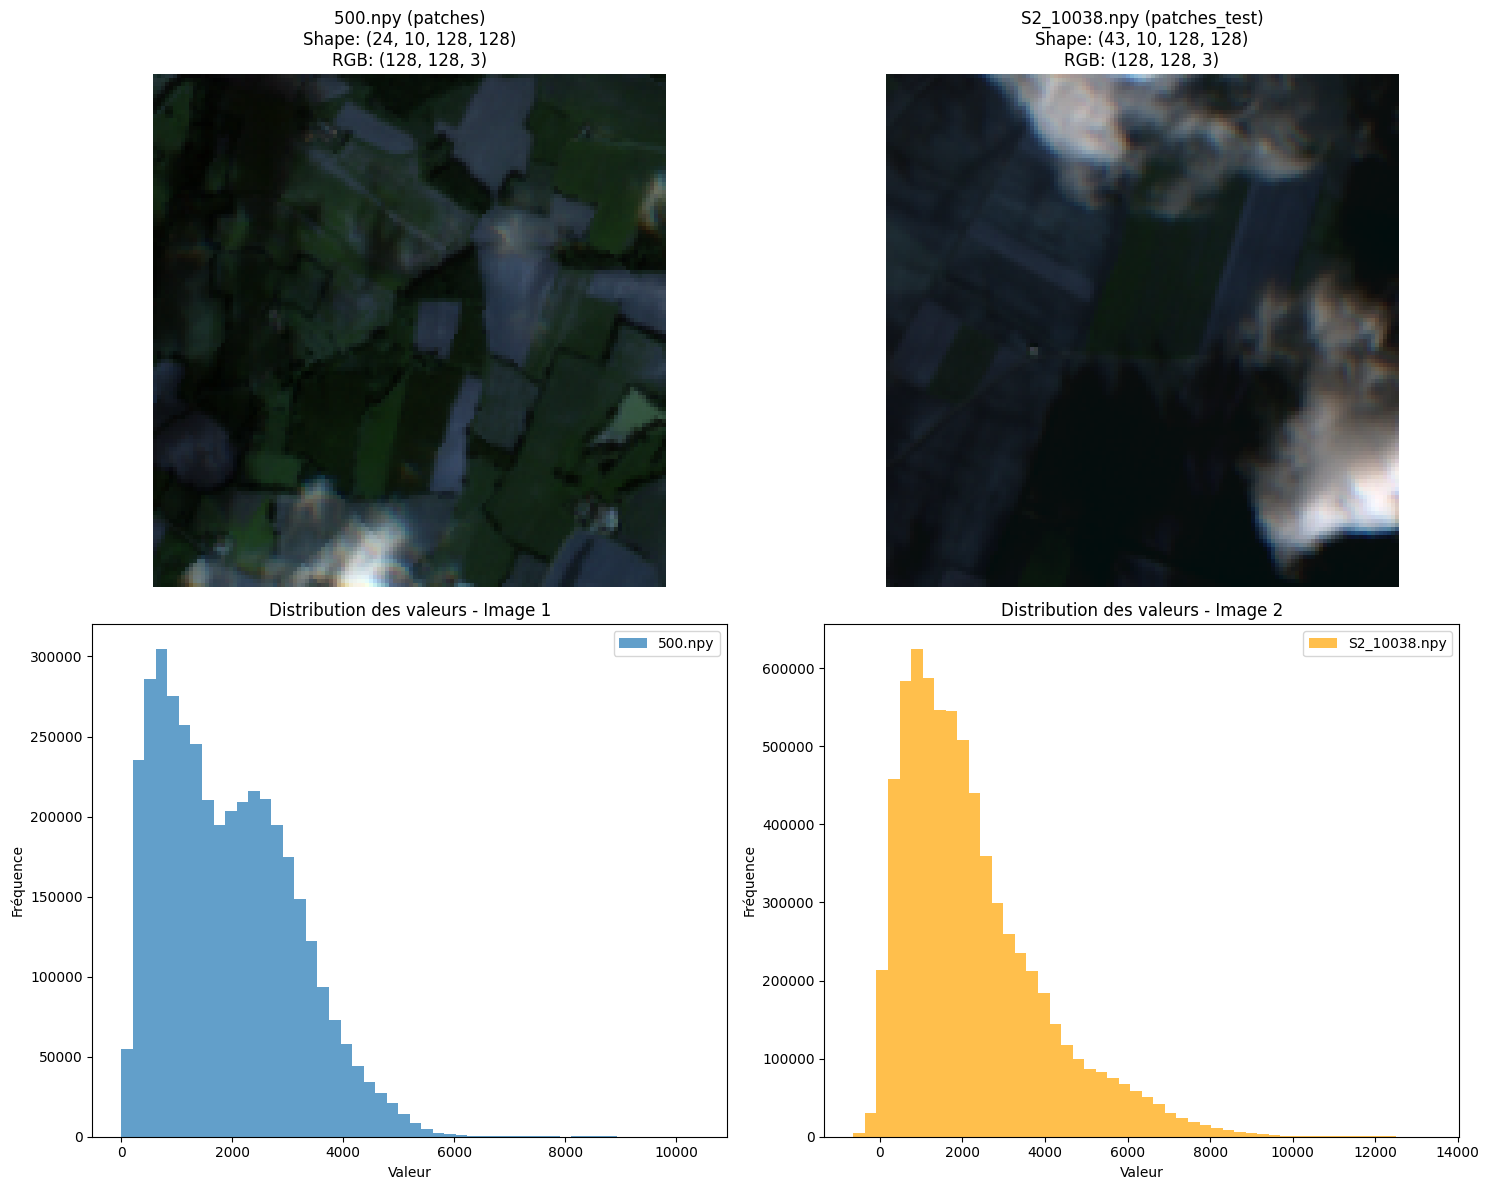


=== ANALYSE DES BANDES SPECTRALES ===

--- Analyse spectrale pour 500.npy ---
Nombre de bandes spectrales : 10


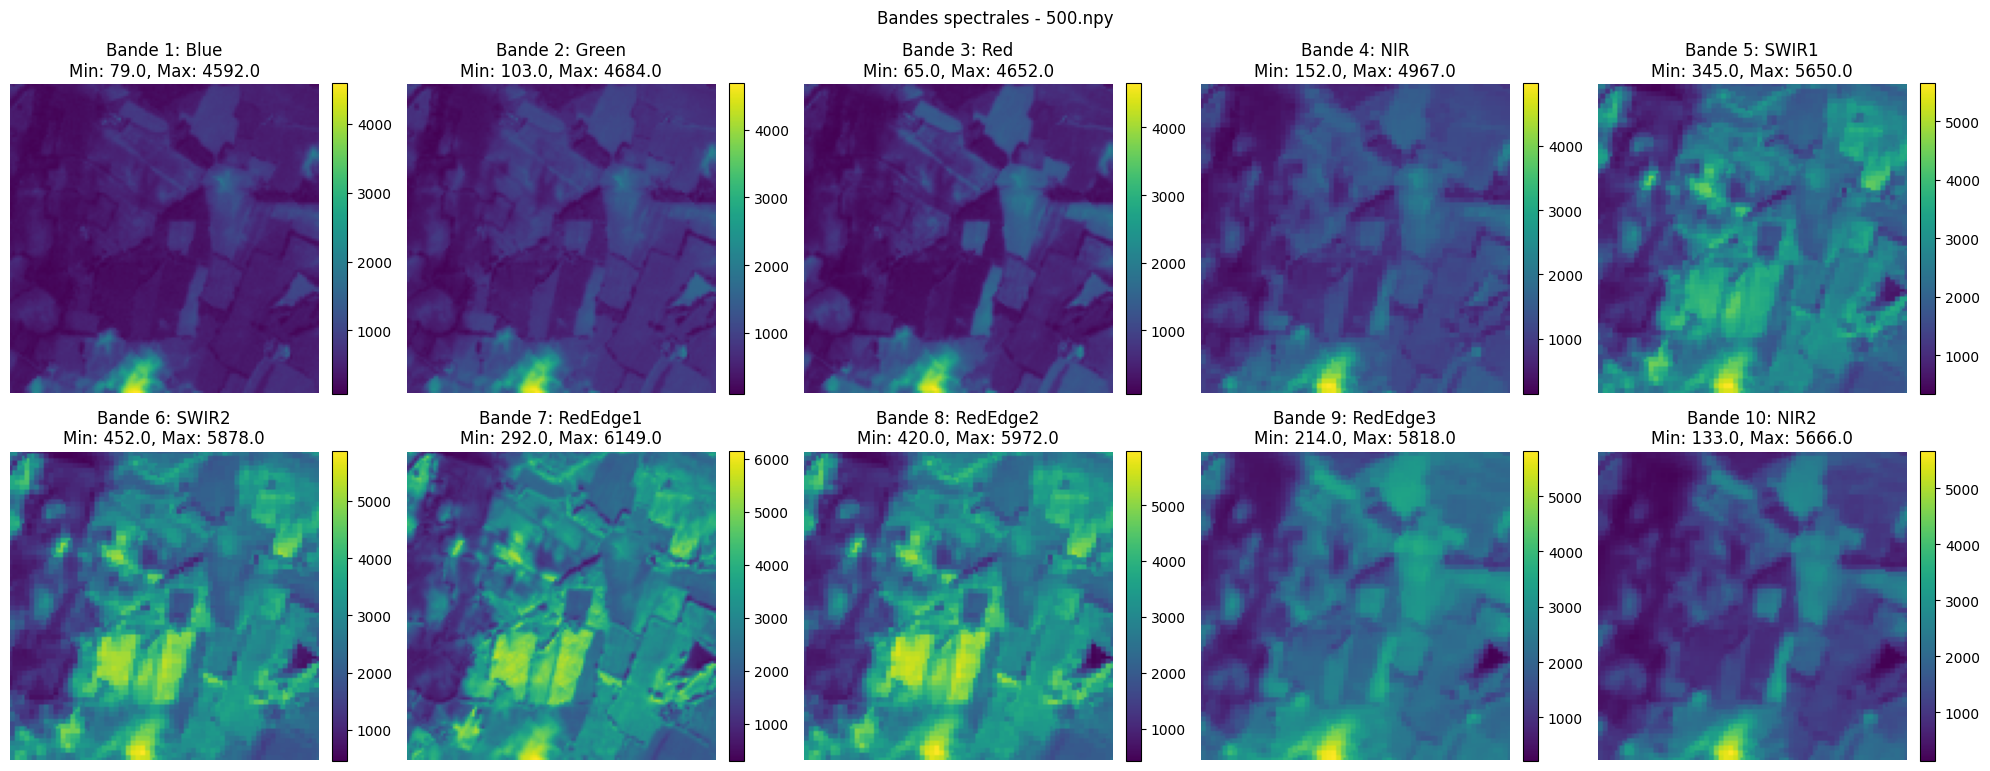


--- Analyse spectrale pour S2_10038.npy ---
Nombre de bandes spectrales : 10


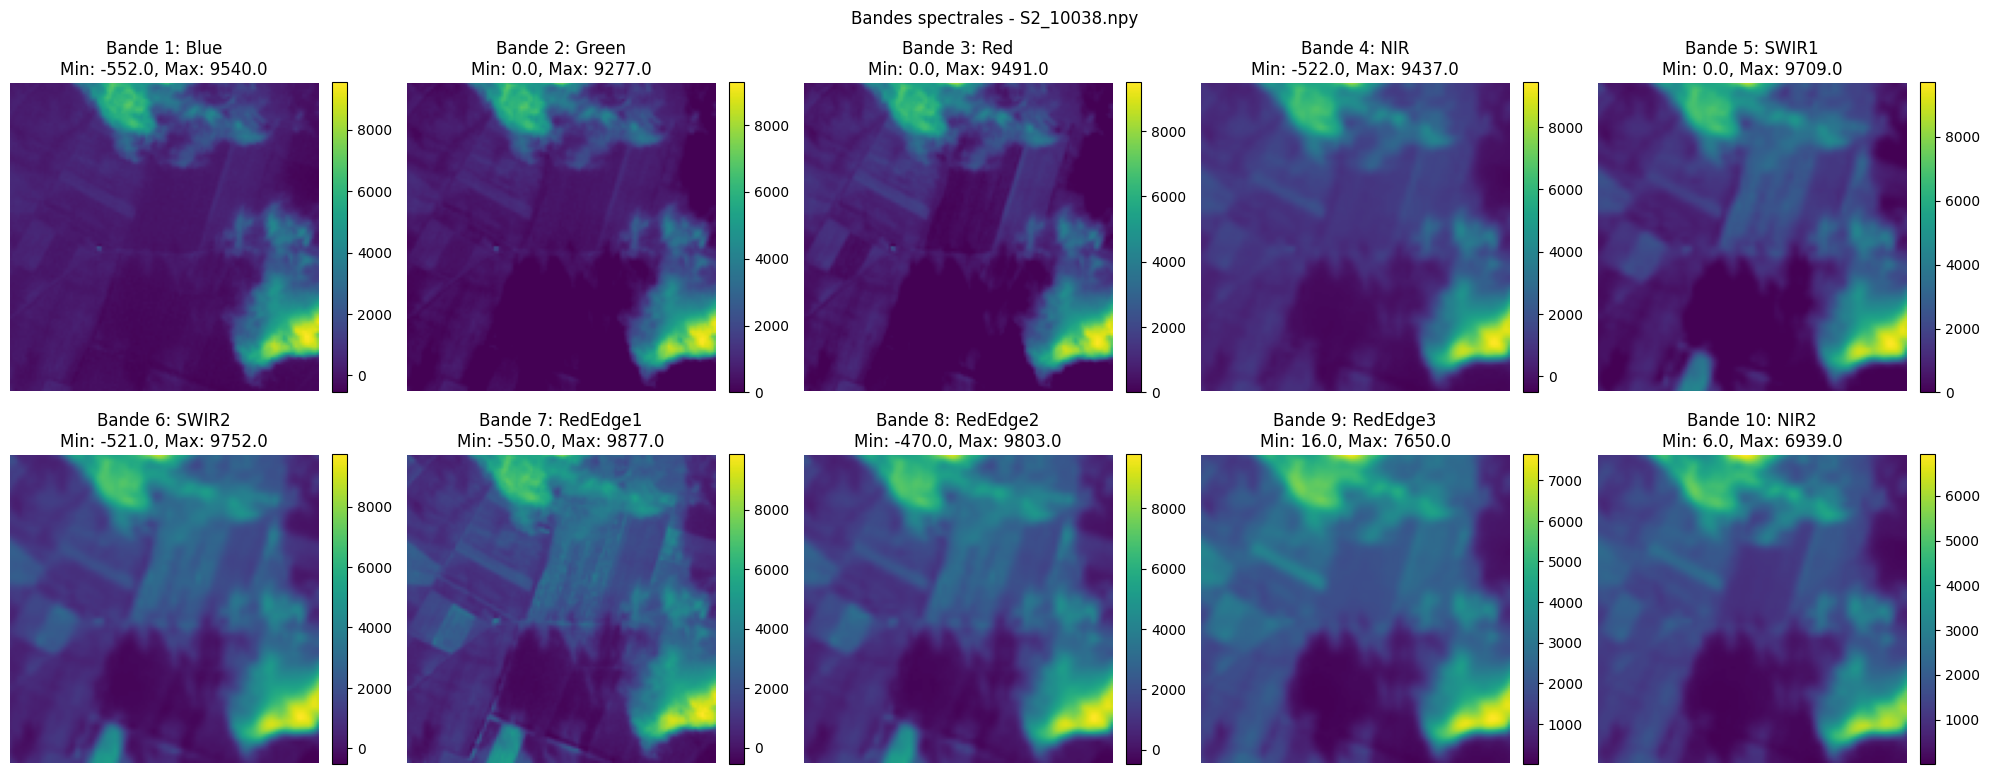


=== COMPARAISON STATISTIQUE ===
Statistique     Image 1 (patches)    Image 2 (patches_test)
------------------------------------------------------------
Nom             500.npy              S2_10038.npy        
Shape           (24, 10, 128, 128)   (43, 10, 128, 128)  
Min             1.00                 -642.00             
Max             10392.00             13334.00            
Mean            1916.44              2237.37             
Std             1186.69              1702.09             
Size (MB)       30.00                13.44               

=== ANALYSE TEMPORELLE (S2_10038.npy) ===
Nombre de timesteps : 43


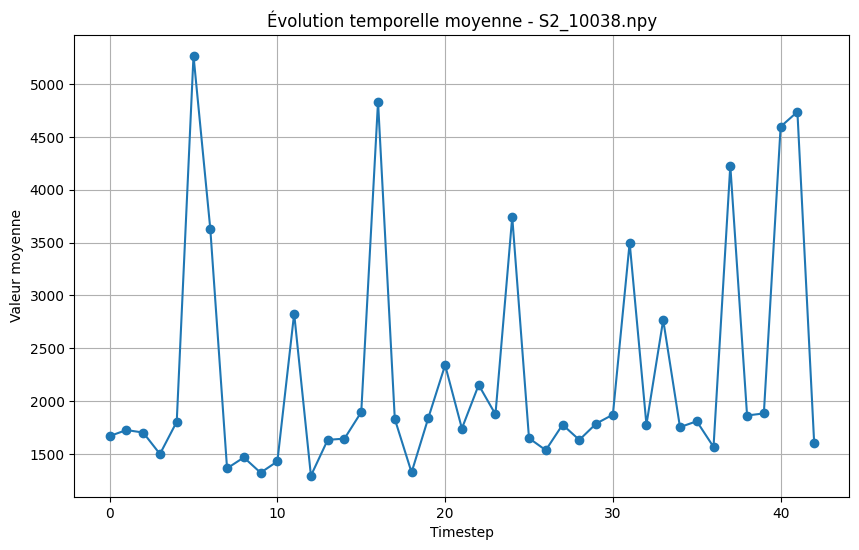


=== COMPARAISON TEMPORELLE ===


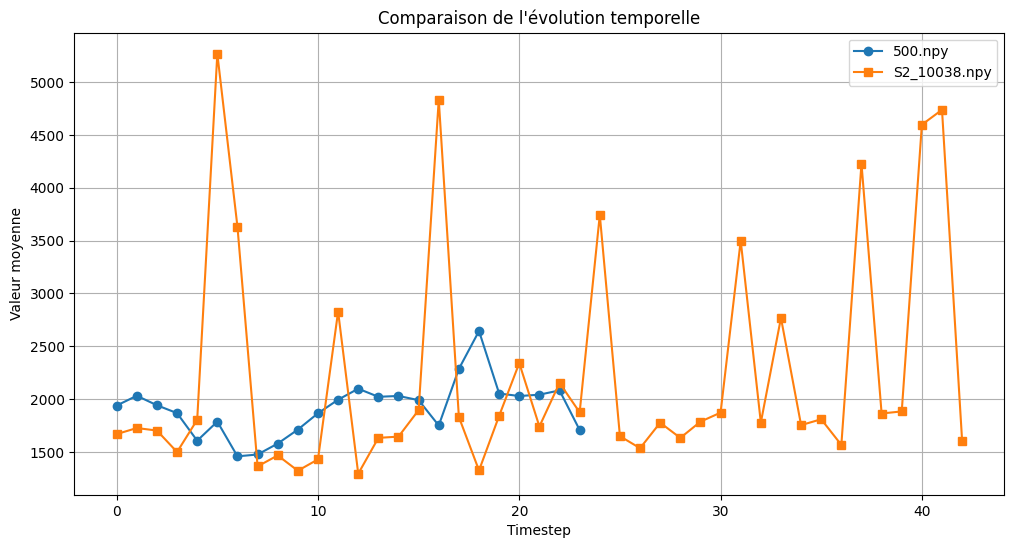

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import s3fs
import os
from PIL import Image

# Configuration S3
BUCKET_NAME = "antoinelesauvage"
S3_PREFIX_PATCHES = "vergers-france/patches_2018_128_10/"
S3_PREFIX_PATCHES_TEST = "vergers-france/patches_test/"  # Nouveau dossier

os.environ["AWS_ACCESS_KEY_ID"] = 'CDFEWKLZRM0VAJRQCSLU'
os.environ["AWS_SECRET_ACCESS_KEY"] = 'KIRHpMn0NCaR31GRgfXJbt3CO1TdOPStlmzumRVN'
os.environ["AWS_SESSION_TOKEN"] = 'eyJhbGciOiJIUzUxMiIsInR5cCI6IkpXVCJ9.eyJhY2Nlc3NLZXkiOiJDREZFV0tMWlJNMFZBSlJRQ1NMVSIsImFsbG93ZWQtb3JpZ2lucyI6WyIqIl0sImF1ZCI6WyJtaW5pby1kYXRhbm9kZSIsIm9ueXhpYSIsImFjY291bnQiXSwiYXV0aF90aW1lIjoxNzU2Mjc4OTMwLCJhenAiOiJvbnl4aWEiLCJlbWFpbCI6ImFudG9pbmUubGVzYXV2YWdlQGFncmljdWx0dXJlLmdvdXYuZnIiLCJlbWFpbF92ZXJpZmllZCI6dHJ1ZSwiZXhwIjoxNzU2ODg0NTYwLCJmYW1pbHlfbmFtZSI6IkxFU0FVVkFHRSIsImdpdmVuX25hbWUiOiJBbnRvaW5lIiwiZ3JvdXBzIjpbIlVTRVJfT05ZWElBIl0sImlhdCI6MTc1NjI3OTc2MCwiaXNzIjoiaHR0cHM6Ly9hdXRoLmxhYi5zc3BjbG91ZC5mci9hdXRoL3JlYWxtcy9zc3BjbG91ZCIsImp0aSI6Im9ucnRydDphNjZkN2I5OS1iMmExLTNkOWEtMmM0ZS02N2MyNDNlZjYyMzYiLCJsb2NhbGUiOiJmciIsIm5hbWUiOiJBbnRvaW5lIExFU0FVVkFHRSIsInBvbGljeSI6InN0c29ubHkiLCJwcmVmZXJyZWRfdXNlcm5hbWUiOiJhbnRvaW5lbGVzYXV2YWdlIiwicmVhbG1fYWNjZXNzIjp7InJvbGVzIjpbIm9mZmxpbmVfYWNjZXNzIiwidW1hX2F1dGhvcml6YXRpb24iLCJkZWZhdWx0LXJvbGVzLXNzcGNsb3VkIl19LCJyZXNvdXJjZV9hY2Nlc3MiOnsiYWNjb3VudCI6eyJyb2xlcyI6WyJtYW5hZ2UtYWNjb3VudCIsIm1hbmFnZS1hY2NvdW50LWxpbmtzIiwidmlldy1wcm9maWxlIl19fSwicm9sZXMiOlsib2ZmbGluZV9hY2Nlc3MiLCJ1bWFfYXV0aG9yaXphdGlvbiIsImRlZmF1bHQtcm9sZXMtc3NwY2xvdWQiXSwic2NvcGUiOiJvcGVuaWQgcHJvZmlsZSBncm91cHMgZW1haWwiLCJzaWQiOiI4YmYwYzU2ZC1lZjAzLTQ0NzMtYmM4MS1jMjEyMDM2OGJhMzIiLCJzdWIiOiJlOWY4NjIyYy01MzQ2LTRjOGUtOWZmYi1jY2MwMzZjY2ZjZjciLCJ0eXAiOiJCZWFyZXIifQ.o9BplqRnv6Hbu6K_kNmRgGeZ-x5PXWye4lcJVYrKshO0SRhvXKhLaluuYvP6Og-t5yVKaW-8y0zoHFW_e98XYQ'
os.environ["AWS_DEFAULT_REGION"] = 'us-east-1'
s3 = s3fs.S3FileSystem(
    client_kwargs={'endpoint_url': 'https://'+'minio.lab.sspcloud.fr'},
    key = os.environ["AWS_ACCESS_KEY_ID"], 
    secret = os.environ["AWS_SECRET_ACCESS_KEY"], 
    token = os.environ["AWS_SESSION_TOKEN"])

patches_path = f"{BUCKET_NAME}/{S3_PREFIX_PATCHES}"
patches_test_path = f"{BUCKET_NAME}/{S3_PREFIX_PATCHES_TEST}"

def load_and_analyze_image(s3_path, image_name):
    """Charge et analyse une image depuis S3"""
    try:
        full_path = f"s3://{s3_path}{image_name}"
        print(f"\n=== Analyse de {image_name} ===")
        print(f"Chargement de : {full_path}")
        
        with s3.open(full_path, 'rb') as f:
            img_array = np.load(f)
            
        print(f"Shape : {img_array.shape}")
        print(f"Dtype : {img_array.dtype}")
        print(f"Min/Max : {img_array.min():.2f}/{img_array.max():.2f}")
        print(f"Mean : {img_array.mean():.2f}")
        print(f"Std : {img_array.std():.2f}")
        
        return img_array, True
        
    except Exception as e:
        print(f"Erreur lors du chargement de {image_name}: {e}")
        return None, False

def convert_to_rgb(img_array, image_name):
    """Convertit une image en format RGB pour visualisation"""
    print(f"\n--- Conversion RGB pour {image_name} ---")
    
    if len(img_array.shape) == 4:
        # Format 4D : probablement (time_steps, channels, H, W) ou similaire
        print(f"Format 4D détecté : {img_array.shape}")
        
        # Stratégies de conversion
        if img_array.shape[0] >= 10 and img_array.shape[1] >= 3:  # (time, channels, H, W)
            # Prendre le dernier timestep et les 3 premiers canaux (RGB)
            img_rgb = img_array[-1, :3, :, :]  # (3, H, W)
            img_rgb = np.transpose(img_rgb, (1, 2, 0))  # (H, W, 3)
            print(f"Méthode: Dernier timestep, 3 premiers canaux")
            
        elif img_array.shape[1] >= 10 and img_array.shape[0] >= 3:  # (channels, time, H, W)
            img_rgb = img_array[:3, -1, :, :]  # (3, H, W)
            img_rgb = np.transpose(img_rgb, (1, 2, 0))  # (H, W, 3)
            print(f"Méthode: 3 premiers canaux, dernier timestep")
            
        else:
            # Fallback : moyenner et créer RGB artificiel
            img_mean = np.mean(img_array, axis=(0, 1))  # Moyenner les deux premières dimensions
            img_rgb = np.stack([img_mean] * 3, axis=-1)
            print(f"Méthode: Moyenne puis duplication en RGB")
            
    elif len(img_array.shape) == 3:
        if img_array.shape[2] == 3:  # (H, W, 3) - déjà RGB
            img_rgb = img_array
            print(f"Méthode: Déjà en format RGB")
            
        elif img_array.shape[0] == 3:  # (3, H, W) - RGB transposé
            img_rgb = np.transpose(img_array, (1, 2, 0))
            print(f"Méthode: Transposition (3,H,W) -> (H,W,3)")
            
        elif img_array.shape[2] > 3:  # (H, W, C) avec C > 3
            img_rgb = img_array[:, :, :3]
            print(f"Méthode: 3 premiers canaux")
            
        else:
            # Moyenne et duplication
            img_mean = np.mean(img_array, axis=2)
            img_rgb = np.stack([img_mean] * 3, axis=-1)
            print(f"Méthode: Moyenne des canaux puis duplication")
            
    elif len(img_array.shape) == 2:  # (H, W) - niveaux de gris
        img_rgb = np.stack([img_array] * 3, axis=-1)
        print(f"Méthode: Duplication niveaux de gris")
        
    else:
        print(f"Format non géré : {img_array.shape}")
        return None
    
    # Normalisation à [0, 255]
    if img_rgb.max() > 255 or img_rgb.min() < 0:
        img_rgb = ((img_rgb - img_rgb.min()) / (img_rgb.max() - img_rgb.min()) * 255)
    
    img_rgb = np.clip(img_rgb, 0, 255).astype(np.uint8)
    
    print(f"RGB final : {img_rgb.shape}, min/max: {img_rgb.min()}/{img_rgb.max()}")
    return img_rgb

def analyze_spectral_bands(img_array, image_name):
    """Analyse les bandes spectrales d'une image"""
    print(f"\n--- Analyse spectrale pour {image_name} ---")
    
    if len(img_array.shape) == 4:
        if img_array.shape[1] >= 10:  # Probablement des bandes spectrales
            # Prendre le dernier timestep
            bands = img_array[-1, :, :, :]  # (bands, H, W)
            
            print(f"Nombre de bandes spectrales : {bands.shape[0]}")
            
            # Noms typiques des bandes Sentinel-2
            band_names = ['Blue', 'Green', 'Red', 'NIR', 'SWIR1', 'SWIR2', 'RedEdge1', 'RedEdge2', 'RedEdge3', 'NIR2']
            
            fig, axes = plt.subplots(2, 5, figsize=(20, 8))
            axes = axes.flatten()
            
            for i in range(min(10, bands.shape[0])):
                band = bands[i, :, :]
                im = axes[i].imshow(band, cmap='viridis')
                axes[i].set_title(f'Bande {i+1}: {band_names[i] if i < len(band_names) else f"Band_{i+1}"}\n'
                                f'Min: {band.min():.1f}, Max: {band.max():.1f}')
                axes[i].axis('off')
                plt.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)
            
            plt.suptitle(f'Bandes spectrales - {image_name}')
            plt.tight_layout()
            plt.show()
            
            return bands
        
    elif len(img_array.shape) == 3 and img_array.shape[2] > 3:
        # Format (H, W, bands)
        print(f"Nombre de bandes spectrales : {img_array.shape[2]}")
        
        fig, axes = plt.subplots(2, 5, figsize=(20, 8))
        axes = axes.flatten()
        
        for i in range(min(10, img_array.shape[2])):
            band = img_array[:, :, i]
            im = axes[i].imshow(band, cmap='viridis')
            axes[i].set_title(f'Bande {i+1}\nMin: {band.min():.1f}, Max: {band.max():.1f}')
            axes[i].axis('off')
            plt.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)
        
        plt.suptitle(f'Bandes spectrales - {image_name}')
        plt.tight_layout()
        plt.show()
        
        return img_array
    
    return None

def list_files_in_directories():
    """Liste les fichiers dans les deux dossiers"""
    print("=== CONTENU DES DOSSIERS ===")
    
    # Lister patches
    print(f"\n--- Fichiers dans {S3_PREFIX_PATCHES} ---")
    try:
        files_patches = s3.ls(patches_path)
        valid_patches = [f for f in files_patches if not os.path.basename(f).startswith('.') and f.endswith('.npy')]
        print(f"Nombre de fichiers .npy : {len(valid_patches)}")
        for i, f in enumerate(valid_patches[:5]):  # Afficher les 5 premiers
            print(f"  {i+1}: {os.path.basename(f)}")
        if len(valid_patches) > 5:
            print(f"  ... et {len(valid_patches) - 5} autres")
    except Exception as e:
        print(f"Erreur : {e}")
    
    # Lister patches_test
    print(f"\n--- Fichiers dans {S3_PREFIX_PATCHES_TEST} ---")
    try:
        files_patches_test = s3.ls(patches_test_path)
        valid_patches_test = [f for f in files_patches_test if not os.path.basename(f).startswith('.') and f.endswith('.npy')]
        print(f"Nombre de fichiers .npy : {len(valid_patches_test)}")
        for i, f in enumerate(valid_patches_test[:10]):  # Afficher les 10 premiers
            print(f"  {i+1}: {os.path.basename(f)}")
        if len(valid_patches_test) > 10:
            print(f"  ... et {len(valid_patches_test) - 10} autres")
            
        # Vérifier si S2_10001.npy existe
        s2_file_exists = any('S2_10038.npy' in f for f in files_patches_test)
        print(f"\nS2_10004.npy trouvé : {'✓' if s2_file_exists else '✗'}")
        
    except Exception as e:
        print(f"Erreur : {e}")

def compare_images():
    """Compare deux images satellite"""
    
    # Lister les fichiers disponibles
    list_files_in_directories()
    
    # Charger la première image (tuile normale)
    print("\n=== CHARGEMENT DES IMAGES ===")
    
    # Prendre la première tuile disponible dans patches
    try:
        pred_files = s3.ls(patches_path)
        valid_files = [f for f in pred_files if not os.path.basename(f).startswith('.') and f.endswith('.npy')]
        
        if not valid_files:
            print("Aucun fichier trouvé dans patches")
            return
        
        # Prendre la première tuile normale (par exemple 0.npy)
        normal_tile = "10"
        for f in valid_files:
            basename = os.path.basename(f)
            if basename.split('.')[0].isdigit():
                normal_tile = "500.npy"
                break
        
        if not normal_tile:
            normal_tile = os.path.basename(valid_files[0])
        
        print(f"Tuile normale sélectionnée : {normal_tile}")
        
    except Exception as e:
        print(f"Erreur lors de la sélection de la tuile normale : {e}")
        return
    
    # Charger les deux images
    img1, success1 = load_and_analyze_image(patches_path, normal_tile)
    img2, success2 = load_and_analyze_image(patches_test_path, "S2_10038.npy")  # Chemin modifié
    
    if not success1 or not success2:
        print("Erreur lors du chargement des images")
        return
    
    # Conversion en RGB pour visualisation
    print("\n=== CONVERSION RGB ===")
    rgb1 = convert_to_rgb(img1, normal_tile)
    rgb2 = convert_to_rgb(img2, "S2_10038.npy")
    
    if rgb1 is None or rgb2 is None:
        print("Erreur lors de la conversion RGB")
        return
    
    # Visualisation côte à côte
    print("\n=== VISUALISATION COMPARATIVE ===")
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # Images RGB
    axes[0, 0].imshow(rgb1)
    axes[0, 0].set_title(f'{normal_tile} (patches)\nShape: {img1.shape}\nRGB: {rgb1.shape}')
    axes[0, 0].axis('off')
    
    axes[0, 1].imshow(rgb2)
    axes[0, 1].set_title(f'S2_10038.npy (patches_test)\nShape: {img2.shape}\nRGB: {rgb2.shape}')
    axes[0, 1].axis('off')
    
    # Histogrammes des valeurs
    axes[1, 0].hist(img1.flatten(), bins=50, alpha=0.7, label=normal_tile)
    axes[1, 0].set_title('Distribution des valeurs - Image 1')
    axes[1, 0].set_xlabel('Valeur')
    axes[1, 0].set_ylabel('Fréquence')
    axes[1, 0].legend()
    
    axes[1, 1].hist(img2.flatten(), bins=50, alpha=0.7, label='S2_10038.npy', color='orange')
    axes[1, 1].set_title('Distribution des valeurs - Image 2')
    axes[1, 1].set_xlabel('Valeur')
    axes[1, 1].set_ylabel('Fréquence')
    axes[1, 1].legend()
    
    plt.tight_layout()
    plt.show()
    
    # Analyse des bandes spectrales
    print("\n=== ANALYSE DES BANDES SPECTRALES ===")
    
    # Analyser les bandes spectrales si disponibles
    bands1 = analyze_spectral_bands(img1, normal_tile)
    bands2 = analyze_spectral_bands(img2, "S2_10038.npy")
    
    # Comparaison statistiques
    print("\n=== COMPARAISON STATISTIQUE ===")
    print(f"{'Statistique':<15} {'Image 1 (patches)':<20} {'Image 2 (patches_test)':<20}")
    print("-" * 60)
    print(f"{'Nom':<15} {normal_tile:<20} {'S2_10038.npy':<20}")
    print(f"{'Shape':<15} {str(img1.shape):<20} {str(img2.shape):<20}")
    print(f"{'Min':<15} {img1.min():<20.2f} {img2.min():<20.2f}")
    print(f"{'Max':<15} {img1.max():<20.2f} {img2.max():<20.2f}")
    print(f"{'Mean':<15} {img1.mean():<20.2f} {img2.mean():<20.2f}")
    print(f"{'Std':<15} {img1.std():<20.2f} {img2.std():<20.2f}")
    print(f"{'Size (MB)':<15} {img1.nbytes/1024/1024:<20.2f} {img2.nbytes/1024/1024:<20.2f}")
    
    # Si les images ont des dimensions temporelles, analyser l'évolution
    if len(img2.shape) == 4 and img2.shape[0] > 1:
        print(f"\n=== ANALYSE TEMPORELLE (S2_10038.npy) ===")
        print(f"Nombre de timesteps : {img2.shape[0]}")
        
        # Calculer l'évolution temporelle moyenne
        temporal_evolution = np.mean(img2, axis=(1, 2, 3))  # Moyenne sur (channels, H, W)
        
        plt.figure(figsize=(10, 6))
        plt.plot(temporal_evolution, 'o-')
        plt.title('Évolution temporelle moyenne - S2_10038.npy')
        plt.xlabel('Timestep')
        plt.ylabel('Valeur moyenne')
        plt.grid(True)
        plt.show()
    
    # Analyse comparative si les deux images ont des dimensions temporelles
    if len(img1.shape) == 4 and len(img2.shape) == 4:
        print(f"\n=== COMPARAISON TEMPORELLE ===")
        if img1.shape[0] > 1 and img2.shape[0] > 1:
            temp1 = np.mean(img1, axis=(1, 2, 3))
            temp2 = np.mean(img2, axis=(1, 2, 3))
            
            plt.figure(figsize=(12, 6))
            plt.plot(temp1, 'o-', label=f'{normal_tile}')
            plt.plot(temp2, 's-', label='S2_10038.npy')
            plt.title('Comparaison de l\'évolution temporelle')
            plt.xlabel('Timestep')
            plt.ylabel('Valeur moyenne')
            plt.legend()
            plt.grid(True)
            plt.show()

# Lancer la comparaison
if __name__ == "__main__":
    compare_images()